# Mateusz Mróz | Nr albumu: 251190 | Wprowadzenie do uczenia maszynowego

# 1. Opis problemu

## Temat: Choroby skóry - klasyfikacja chorób erytemato-łuskowych

**Wybrany zbiór danych:** [UCI Dermatology Database](https://archive.ics.uci.edu/dataset/33/dermatology)

### Kontekst problemu

Choroby erytemato-łuskowe (łuszczyca, łojotokowe zapalenie skóry, liszaj płaski, łupież różowy, przewlekłe zapalenie skóry, pityriasis rubra pilaris) mają zbliżone objawy kliniczne - rumień i złuszczanie. **Diagnostyka różnicowa wymaga biopsji**, ale i histopatologia bywa niejednoznaczna. Celem jest model rozpoznający chorobę na podstawie 34 cech klinicznych i histopatologicznych.

**Charakterystyka zbioru:**
- **Liczba instancji:** 366
- **Liczba cech:** 34 (11 klinicznych + 22 histopatologicznych + wiek)
- **Typ problemu:** Klasyfikacja 6-kategoriowa
- **Klasy docelowe:** psoriasis (112), seboreic dermatitis (61), lichen planus (72), pityriasis rosea (49), chronic dermatitis (52), pityriasis rubra pilaris (20)

## Wybór zbioru danych - porównanie 3 kandydatów

Zgodnie z wymaganiem projektu zebrano 3 zbiory danych dotyczące chorób skóry. Wszystkie odpowiadają na ten sam problem dziedzinowy (rozpoznanie typu choroby skóry), różniąc się modalnością danych. Do dalszej analizy wybrano dataset z najlepszą charakterystyką dla klasycznego pipeline'u ML (tabelaryczny, czysty, dobrze udokumentowany w literaturze).

| Lp. | Dataset | Typ | Rozmiar | Objętość | Klasy | Licencja | Status |
|-----|---------|-----|---------|----------|-------|----------|--------|
| 1.1 | [UCI Dermatology](https://archive.ics.uci.edu/dataset/33/dermatology) | tabelaryczny | 366 × 34 | ~110 KB (CSV) | 6 dermatoz | CC BY 4.0 | **Wybrany** |
| 1.2 | [ACNE04 (Hayashi grading)](https://github.com/xpwu95/LDL) | obrazy | 1 457 zdjęć | ~1.2 GB (JPG) | 4 (skala Hayashi) | research-only | Odrzucony |
| 1.3 | [PAD-UFES-20](https://data.mendeley.com/datasets/zr7vgbcyr2/1) | obrazy + metadane | 2 298 zdjęć | PNG + CSV | 6 klas zmian skórnych | CC BY 4.0 | Odrzucony |

### Uzasadnienie wyboru UCI Dermatology

- **Forma tabelaryczna** - pozwala zastosować klasyczne metody ML bez GPU.
- **Dlaczego nie PAD-UFES-20:** jest osobnym, niedublującym się zbiorem, ale wymaga pipeline'u obrazowego/CNN i większych zasobów obliczeniowych.
- **Wysoka jakość danych** - tylko 8 braków (kolumna `age`), reszta cech kompletna w skali 0-3.
- **Klasyczny benchmark** - publikacje peer-review z mierzalnymi wynikami (Güvenir 1998, Xie 2011, Abdi 2013) - patrz sekcja 9.
- **Interpretowalność** - nazwane cechy medyczne pozwalają na sensowną analizę SHAP i feature importance.
- **Realny problem kliniczny** - diagnostyka różnicowa, gdzie nawet lekarz potrzebuje biopsji.

## a) Opis zmiennych w zbiorze danych

| Nazwa zmiennej | Rola | Typ | Opis | Braki |
|----------------|------|-----|------|-------|
| erythema | Cecha | Całkowita | Rumień (0-3) | Nie |
| scaling | Cecha | Całkowita | Złuszczanie (0-3) | Nie |
| definite_borders | Cecha | Całkowita | Wyraźne granice zmiany (0-3) | Nie |
| itching | Cecha | Całkowita | Świąd (0-3) | Nie |
| koebner_phenomenon | Cecha | Całkowita | Objaw Koebnera - pojawienie się zmian w miejscu urazu (0-3) | Nie |
| polygonal_papules | Cecha | Całkowita | Grudki wielokątne (0-3) | Nie |
| follicular_papules | Cecha | Całkowita | Grudki przymieszkowe (0-3) | Nie |
| oral_mucosal_involvement | Cecha | Całkowita | Zajęcie błony śluzowej jamy ustnej (0-3) | Nie |
| knee_and_elbow_involvement | Cecha | Całkowita | Zajęcie kolan i łokci (0-3) | Nie |
| scalp_involvement | Cecha | Całkowita | Zajęcie skóry głowy (0-3) | Nie |
| family_history | Cecha | Binarna | Historia rodzinna choroby: 1 - tak, 0 - nie | Nie |
| melanin_incontinence | Cecha | Całkowita | Nietrzymanie melaniny (0-3) | Nie |
| eosinophils_in_infiltrate | Cecha | Całkowita | Eozynofile w nacieku (0-3) | Nie |
| pnl_infiltrate | Cecha | Całkowita | Naciek wielojądrzastych (PNL) (0-3) | Nie |
| fibrosis_papillary_dermis | Cecha | Całkowita | Włóknienie skóry brodawkowatej (0-3) | Nie |
| exocytosis | Cecha | Całkowita | Egzocytoza (0-3) | Nie |
| acanthosis | Cecha | Całkowita | Akantoza - pogrubienie warstwy kolczystej (0-3) | Nie |
| hyperkeratosis | Cecha | Całkowita | Hiperkeratoza - nadmierne rogowacenie (0-3) | Nie |
| parakeratosis | Cecha | Całkowita | Parakeratoza - niepełne rogowacenie (0-3) | Nie |
| clubbing_rete_ridges | Cecha | Całkowita | Maczugowate sople nabłonkowe (0-3) | Nie |
| elongation_rete_ridges | Cecha | Całkowita | Wydłużenie sopli nabłonkowych (0-3) | Nie |
| thinning_suprapapillary_epidermis | Cecha | Całkowita | Ścieńczenie naskórka nadbrodawkowego (0-3) | Nie |
| spongiform_pustule | Cecha | Całkowita | Krosta gąbczasta (0-3) | Nie |
| munro_microabcess | Cecha | Całkowita | Mikroropień Munro (0-3) | Nie |
| focal_hypergranulosis | Cecha | Całkowita | Ogniskowa hipergranuloza (0-3) | Nie |
| disappearance_granular_layer | Cecha | Całkowita | Zanik warstwy ziarnistej (0-3) | Nie |
| vacuolisation_damage_basal_layer | Cecha | Całkowita | Wakuolizacja i uszkodzenie warstwy podstawnej (0-3) | Nie |
| spongiosis | Cecha | Całkowita | Spongioza - obrzęk międzykomórkowy (0-3) | Nie |
| saw_tooth_retes | Cecha | Całkowita | Sople nabłonkowe w kształcie zębów piły (0-3) | Nie |
| follicular_horn_plug | Cecha | Całkowita | Czopy rogowe w mieszkach (0-3) | Nie |
| perifollicular_parakeratosis | Cecha | Całkowita | Parakeratoza okołomieszkowa (0-3) | Nie |
| inflammatory_mononuclear_infiltrate | Cecha | Całkowita | Naciek jednojądrzastych komórek zapalnych (0-3) | Nie |
| band_like_infiltrate | Cecha | Całkowita | Naciek wstęgowaty (0-3) | Nie |
| age | Cecha | Ciągła | Wiek pacjenta w latach | Tak (8) |
| class | Cel | Kategoryczna | Choroba: 1 - psoriasis, 2 - seboreic dermatitis, 3 - lichen planus, 4 - pityriasis rosea, 5 - chronic dermatitis, 6 - pityriasis rubra pilaris | Nie |


## b) Import bibliotek


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC

import shap
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paleta kolorów :)
warm_colors = ['#FF6B6B', '#FF8E53', '#FFB347', '#E91E63', '#FF5722', '#FFC371']
warm_cmap = LinearSegmentedColormap.from_list("warm", ["#E91E63", "#FF6B6B", "#FF8E53", "#FFB347", "#FF5722"])

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 40)


C:\Users\MattyMroz\Desktop\PROJECTS\ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## c) Wczytanie zbioru danych


In [2]:
DATA_PATH = Path("../data/uci_dermatology/dermatology.data")

CLINICAL_FEATURES = [
    "erythema", "scaling", "definite_borders", "itching", "koebner_phenomenon",
    "polygonal_papules", "follicular_papules", "oral_mucosal_involvement",
    "knee_and_elbow_involvement", "scalp_involvement", "family_history",
]
HISTO_FEATURES = [
    "melanin_incontinence", "eosinophils_in_infiltrate", "pnl_infiltrate",
    "fibrosis_papillary_dermis", "exocytosis", "acanthosis", "hyperkeratosis",
    "parakeratosis", "clubbing_rete_ridges", "elongation_rete_ridges",
    "thinning_suprapapillary_epidermis", "spongiform_pustule", "munro_microabcess",
    "focal_hypergranulosis", "disappearance_granular_layer",
    "vacuolisation_damage_basal_layer", "spongiosis", "saw_tooth_retes",
    "follicular_horn_plug", "perifollicular_parakeratosis",
    "inflammatory_mononuclear_infiltrate", "band_like_infiltrate",
]
COLUMNS = CLINICAL_FEATURES + HISTO_FEATURES + ["age", "class"]

CLASS_NAMES = {
    1: "psoriasis",
    2: "seboreic_dermatitis",
    3: "lichen_planus",
    4: "pityriasis_rosea",
    5: "chronic_dermatitis",
    6: "pityriasis_rubra_pilaris",
}

# Wczytanie danych z pliku (separator: przecinek, brakujące: ?)
df = pd.read_csv(DATA_PATH, header=None, names=COLUMNS, na_values="?")
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["class_name"] = df["class"].map(CLASS_NAMES)

df.head()


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_infiltrate,pnl_infiltrate,fibrosis_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_rete_ridges,elongation_rete_ridges,thinning_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class,class_name
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55.0,2,seboreic_dermatitis
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8.0,1,psoriasis
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26.0,3,lichen_planus
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40.0,1,psoriasis
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45.0,3,lichen_planus


In [3]:
# Sprawdzenie wymiarów
print(f"Wymiary zbioru danych: {df.shape[0]} wierszy, {df.shape[1]} kolumn")


Wymiary zbioru danych: 366 wierszy, 36 kolumn


# 2. Opis danych

## a) Statystyki opisowe


In [4]:
# Informacje o zbiorze danych
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   erythema                             366 non-null    int64  
 1   scaling                              366 non-null    int64  
 2   definite_borders                     366 non-null    int64  
 3   itching                              366 non-null    int64  
 4   koebner_phenomenon                   366 non-null    int64  
 5   polygonal_papules                    366 non-null    int64  
 6   follicular_papules                   366 non-null    int64  
 7   oral_mucosal_involvement             366 non-null    int64  
 8   knee_and_elbow_involvement           366 non-null    int64  
 9   scalp_involvement                    366 non-null    int64  
 10  family_history                       366 non-null    int64  
 11  melanin_incontinence                 366 no

In [5]:
# Statystyki opisowe dla numerycznych zmiennych
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.07,0.66,0.0,2.0,2.0,2.00,3.0
scaling,366.0,1.80,0.70,0.0,1.0,2.0,2.00,3.0
definite_borders,366.0,1.55,0.91,0.0,1.0,2.0,2.00,3.0
itching,366.0,1.37,1.14,0.0,0.0,1.0,2.00,3.0
koebner_phenomenon,366.0,0.63,0.91,0.0,0.0,0.0,1.00,3.0
polygonal_papules,366.0,0.45,0.96,0.0,0.0,0.0,0.00,3.0
follicular_papules,366.0,0.17,0.57,0.0,0.0,0.0,0.00,3.0
oral_mucosal_involvement,366.0,0.38,0.83,0.0,0.0,0.0,0.00,3.0
knee_and_elbow_involvement,366.0,0.61,0.98,0.0,0.0,0.0,1.00,3.0
scalp_involvement,366.0,0.52,0.91,0.0,0.0,0.0,1.00,3.0


In [6]:
# Sprawdzenie braków danych
missing = df.isna().sum()
missing[missing > 0]


age    8
dtype: int64

## b) Wizualizacje danych

### Wykres kołowy - rozkład klas


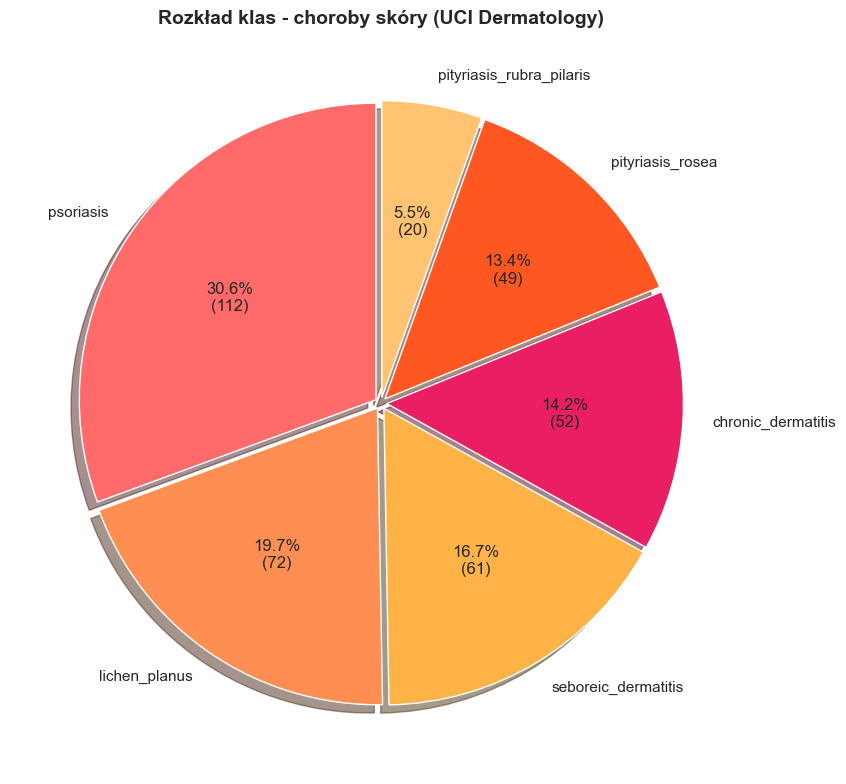

Stosunek większość/mniejszość: 5.60x


In [7]:
# Rozkład zmiennej docelowej
target_counts = df["class_name"].value_counts()


def format_label(pct, values):
    absolute = int(round(pct / 100.0 * sum(values)))
    return f"{pct:.1f}%\n({absolute})"


plt.figure(figsize=(10, 8))
plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct=lambda pct: format_label(pct, target_counts),
    colors=warm_colors[:len(target_counts)],
    startangle=90,
    explode=(0.02,) * len(target_counts),
    shadow=True,
)
plt.title("Rozkład klas - choroby skóry (UCI Dermatology)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Stosunek większość/mniejszość: {target_counts.max() / target_counts.min():.2f}x")


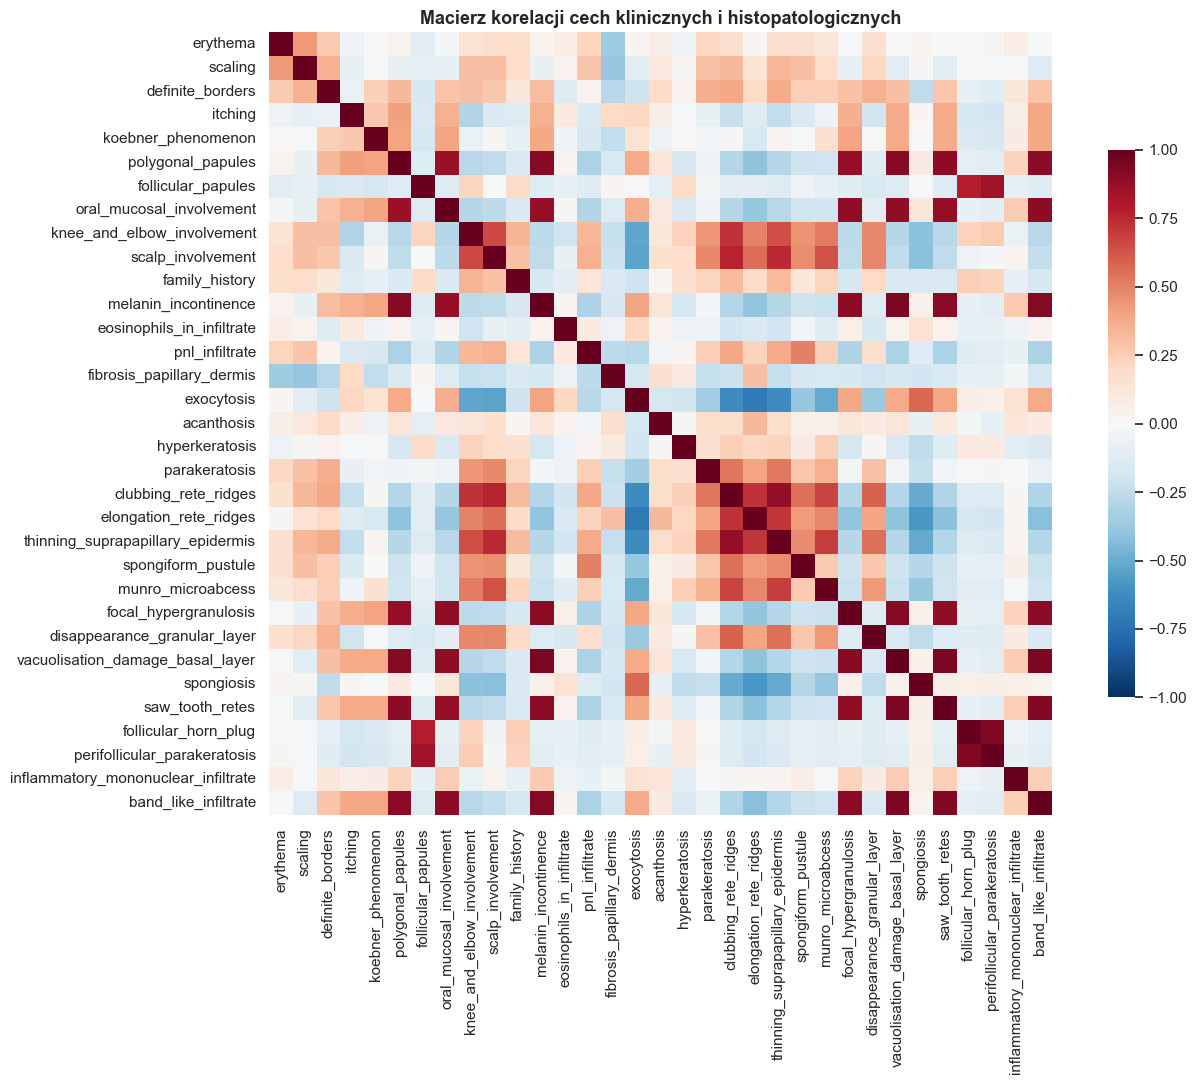

Silnie skorelowane cechy (|r| > 0.7):
vacuolisation_damage_basal_layer  melanin_incontinence                0.941659
saw_tooth_retes                   vacuolisation_damage_basal_layer    0.938397
band_like_infiltrate              vacuolisation_damage_basal_layer    0.937561
perifollicular_parakeratosis      follicular_horn_plug                0.928929
band_like_infiltrate              saw_tooth_retes                     0.928748
                                  melanin_incontinence                0.916848
vacuolisation_damage_basal_layer  polygonal_papules                   0.911626
                                  focal_hypergranulosis               0.909650
melanin_incontinence              polygonal_papules                   0.907044
band_like_infiltrate              polygonal_papules                   0.905822
                                  focal_hypergranulosis               0.904519
saw_tooth_retes                   melanin_incontinence                0.900232
focal_hypergra

In [8]:
# Macierz korelacji cech (bez age)
corr = df[CLINICAL_FEATURES + HISTO_FEATURES].corr()
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Macierz korelacji cech klinicznych i histopatologicznych",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Silnie skorelowane cechy
mask = np.triu(np.ones_like(corr, dtype=bool))
strong_corr = corr.where(~mask).stack()
strong_corr = strong_corr[strong_corr.abs() > 0.7].sort_values(key=lambda s: s.abs(), ascending=False)
print("Silnie skorelowane cechy (|r| > 0.7):")
print(strong_corr.head(15))


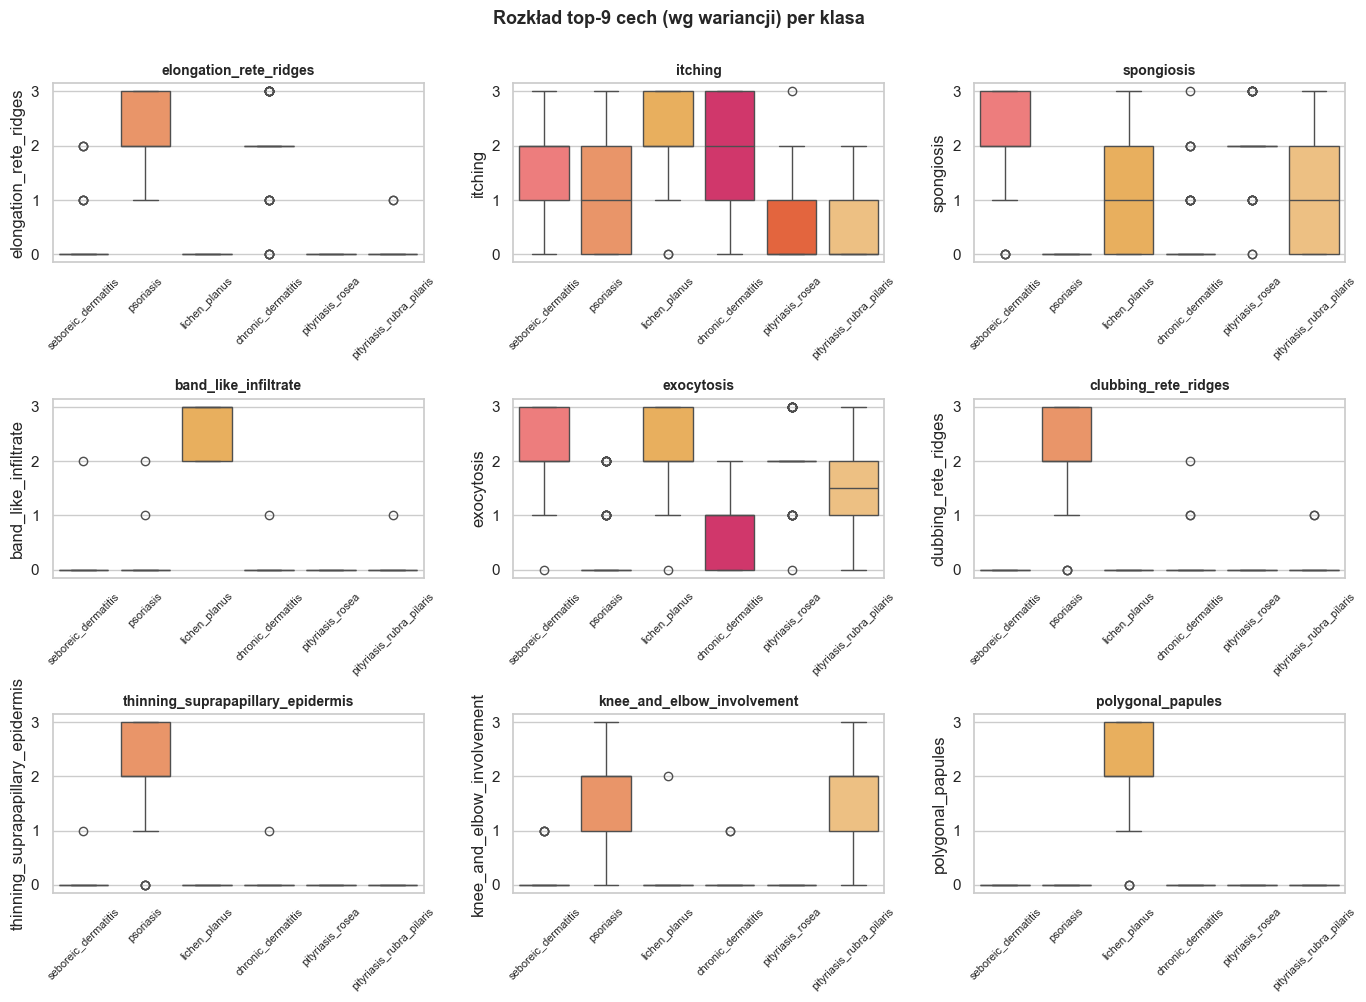

In [9]:
# Boxploty - top 9 cech (wg wariancji) per klasa
top_variance_features = (
    df[CLINICAL_FEATURES + HISTO_FEATURES]
    .var()
    .sort_values(ascending=False)
    .head(9)
    .index
    .tolist()
)

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(14, 10))
axs = axs.flatten()
for idx, feat in enumerate(top_variance_features):
    sns.boxplot(x="class_name", y=feat, data=df, ax=axs[idx],
                hue="class_name", palette=warm_colors, legend=False)
    axs[idx].set_title(feat, fontsize=10, fontweight="bold")
    axs[idx].set_xlabel("")
    axs[idx].tick_params(axis="x", rotation=45, labelsize=8)
plt.suptitle("Rozkład top-9 cech (wg wariancji) per klasa",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()


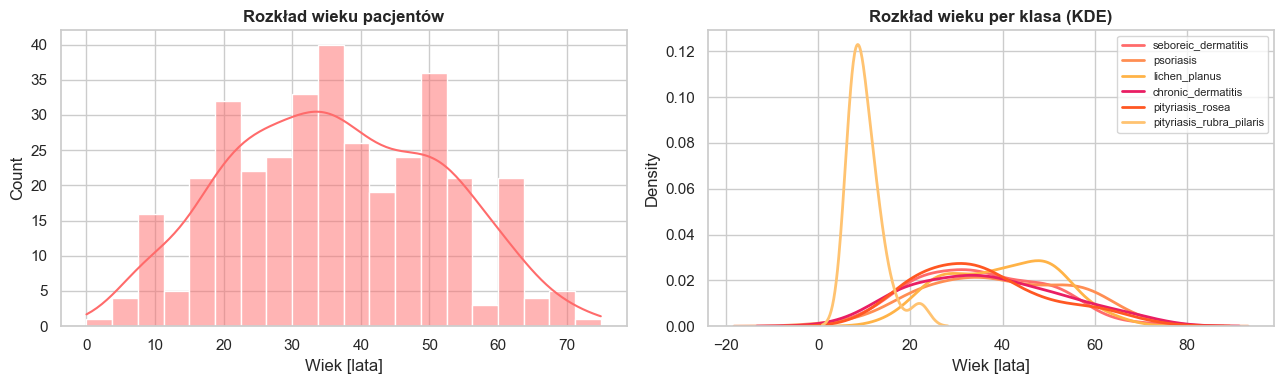

In [10]:
# Histogram wieku + KDE per klasa
fig, axs = plt.subplots(ncols=2, figsize=(13, 4))

sns.histplot(df["age"].dropna(), bins=20, kde=True, ax=axs[0],
             color="#FF6B6B", edgecolor="white")
axs[0].set_title("Rozkład wieku pacjentów", fontweight="bold")
axs[0].set_xlabel("Wiek [lata]")

for i, cls_name in enumerate(df["class_name"].unique()):
    sns.kdeplot(df[df["class_name"] == cls_name]["age"].dropna(),
                label=cls_name, ax=axs[1], linewidth=2,
                color=warm_colors[i % len(warm_colors)])
axs[1].set_title("Rozkład wieku per klasa (KDE)", fontweight="bold")
axs[1].set_xlabel("Wiek [lata]")
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## c) Wnioski z analizy danych

- **Braki:** tylko 8 NaN w `age` -> uzupełnimy medianą.
- **Niezbalansowanie:** stosunek 5.6x (112 vs 20) -> stratyfikowany split + macro-F1 jako główna metryka.
- **Skale cech:** 33 cechy w 0-3, `age` w latach -> konieczne skalowanie dla LR/SVM.
- **Korelacje:** silne pary w cechach histopatologicznych - typowa redundancja w dermatopatologii.


# 3. Preprocessing i podział train/test

Podział 80/20 ze stratyfikacją. Imputacja medianą i skalowanie wewnątrz `Pipeline` - fit tylko na trainie, żeby uniknąć wycieku danych do testu.


In [ ]:
FEATURES = CLINICAL_FEATURES + HISTO_FEATURES + ["age"]

X = df[FEATURES].copy()
y = df["class"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


def make_preprocessor() -> Pipeline:
    """Imputacja medianą + StandardScaler (fit tylko na trainie)"""
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])


print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Rozkład klas (train):", pd.Series(y_train).value_counts().sort_index().tolist())
print("Rozkład klas (test) :", pd.Series(y_test).value_counts().sort_index().tolist())


Train: (292, 34) | Test: (74, 34)
Rozkład klas (train): [89, 49, 57, 39, 42, 16]
Rozkład klas (test) : [23, 12, 15, 10, 10, 4]


# 4. Baseline - Dummy + Logistic Regression

Dummy (`most_frequent`) i Logistic Regression jako baseline. Walidacja: `StratifiedKFold(k=5)`.


In [ ]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}


def evaluate_cv(name: str, estimator: Pipeline, X: pd.DataFrame, y: np.ndarray) -> dict[str, float]:
    """Cross-walidacja 5-fold, zwraca średnie i std głównych metryk"""
    cv_res = cross_validate(
        estimator, X, y, cv=CV, scoring=SCORING, n_jobs=-1, return_train_score=False
    )
    summary = {"model": name}
    for metric in SCORING:
        key = f"test_{metric}"
        summary[f"{metric}_mean"] = cv_res[key].mean()
        summary[f"{metric}_std"] = cv_res[key].std()
    return summary


# Pipeline: preprocessing + model
def build_pipeline(model) -> Pipeline:
    return Pipeline(steps=[("preproc", make_preprocessor()), ("model", model)])


baseline_models = {
    "Dummy (most_frequent)": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
}

baseline_results = [
    evaluate_cv(name, build_pipeline(model), X_train, y_train)
    for name, model in baseline_models.items()
]
baseline_df = pd.DataFrame(baseline_results)
baseline_df.round(4)


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,Dummy (most_frequent),0.3048,0.0063,0.0779,0.0012,0.1424,0.0052
1,Logistic Regression,0.9794,0.0129,0.9768,0.0145,0.9793,0.0129


# 5. Modele - Random Forest, SVM (RBF), XGBoost

Bagging (RF), kernel (SVM RBF), boosting (XGBoost). Wszystkie w tym samym pipeline (preprocessing + model) walidowane na `StratifiedKFold(k=5)`.


In [13]:
# XGBoost wymaga etykiet 0-indexowanych ([0..n_classes-1]); pozostałe modele
# (RF, SVM, LR) akceptują oryginalne 1-6 z UCI bez konwersji.
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# Pipeline'y - wszystkie z tym samym preprocessingiem
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
                     class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        objective="multi:softprob", num_class=6,
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric="mlogloss",
    ),
}

model_results = list(baseline_results)
for name, model in models.items():
    if name == "XGBoost":
        summary = evaluate_cv(name, build_pipeline(model), X_train, y_train_xgb)
    else:
        summary = evaluate_cv(name, build_pipeline(model), X_train, y_train)
    model_results.append(summary)

results_df = pd.DataFrame(model_results)
results_df.round(4)


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,Dummy (most_frequent),0.3048,0.0063,0.0779,0.0012,0.1424,0.0052
1,Logistic Regression,0.9794,0.0129,0.9768,0.0145,0.9793,0.0129
2,Random Forest,0.9760,0.0085,0.9691,0.0151,0.9755,0.0092
3,SVM (RBF),0.9794,0.0129,0.9768,0.0145,0.9793,0.0129
4,XGBoost,0.9690,0.0201,0.9581,0.0310,0.9682,0.0209


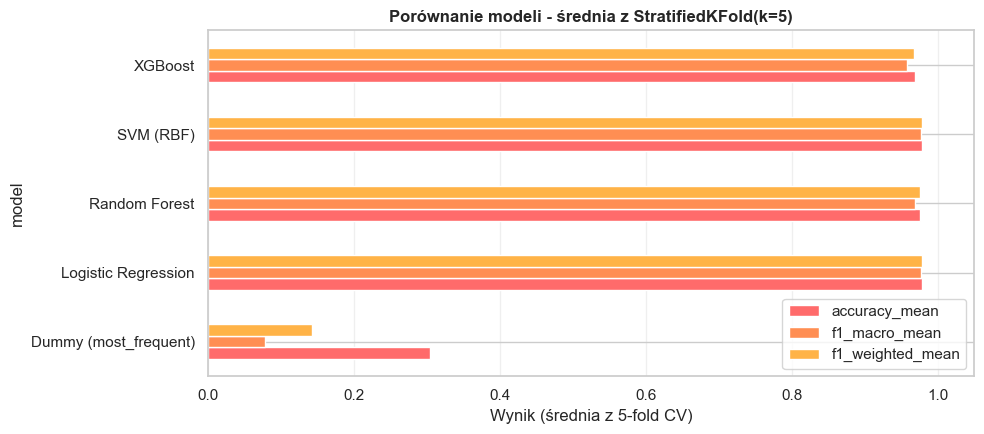


Najlepszy model: Logistic Regression
  f1_macro = 0.9768 ± 0.0145
  accuracy = 0.9794 ± 0.0129


In [14]:
# Porównanie modeli
plot_df = results_df.copy()
plot_df = plot_df.set_index("model")[["accuracy_mean", "f1_macro_mean", "f1_weighted_mean"]]

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_df.plot(kind="barh", ax=ax, color=["#FF6B6B", "#FF8E53", "#FFB347"], edgecolor="white")
ax.set_xlim(0, 1.05)
ax.set_xlabel("Wynik (średnia z 5-fold CV)")
ax.set_title("Porównanie modeli - średnia z StratifiedKFold(k=5)", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

best_row = results_df.sort_values("f1_macro_mean", ascending=False).iloc[0]
print(f"\nNajlepszy model: {best_row['model']}")
print(f"  f1_macro = {best_row['f1_macro_mean']:.4f} ± {best_row['f1_macro_std']:.4f}")
print(f"  accuracy = {best_row['accuracy_mean']:.4f} ± {best_row['accuracy_std']:.4f}")


Wszystkie modele osiągają zbliżone CV accuracy (~96-98%) - brak wyraźnego zwycięzcy. Do strojenia wybieramy **Random Forest** ze względu na interpretowalność (feature importance + SHAP TreeExplainer).


# 6. Strojenie hiperparametrów - Random Forest

`GridSearchCV` z `StratifiedKFold(k=5)` i metryką `f1_macro`. Grid celowo niewielki, by uniknąć over-tuningu na małej próbce.


In [15]:
rf_pipeline = build_pipeline(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
)

param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 8, 16],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

grid = GridSearchCV(
    rf_pipeline, param_grid, cv=CV, scoring="f1_macro", n_jobs=-1, verbose=0
)
grid.fit(X_train, y_train)

print("Najlepsze parametry:")
for k, v in grid.best_params_.items():
    print(f"  {k} = {v}")
print(f"\nBest CV f1_macro: {grid.best_score_:.4f}")


Najlepsze parametry:
  model__max_depth = None
  model__max_features = sqrt
  model__min_samples_leaf = 4
  model__n_estimators = 200

Best CV f1_macro: 0.9810


# 7. Ewaluacja na zbiorze testowym

Ocena modelu na 20% danych odłożonych przy splicie.


In [16]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

test_acc = (y_pred == y_test).mean()
test_f1m = f1_score(y_test, y_pred, average="macro")
test_f1w = f1_score(y_test, y_pred, average="weighted")

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test f1_macro: {test_f1m:.4f}")
print(f"Test f1_weighted: {test_f1w:.4f}\n")

# Pełny raport per-klasa
target_names_ordered = [CLASS_NAMES[i] for i in range(1, 7)]
print(classification_report(y_test, y_pred, target_names=target_names_ordered, digits=4))


Test accuracy: 0.9595
Test f1_macro: 0.9431
Test f1_weighted: 0.9593

                          precision    recall  f1-score   support

               psoriasis     1.0000    1.0000    1.0000        23
     seboreic_dermatitis     0.9091    0.8333    0.8696        12
           lichen_planus     1.0000    1.0000    1.0000        15
        pityriasis_rosea     0.9000    0.9000    0.9000        10
      chronic_dermatitis     1.0000    1.0000    1.0000        10
pityriasis_rubra_pilaris     0.8000    1.0000    0.8889         4

                accuracy                         0.9595        74
               macro avg     0.9348    0.9556    0.9431        74
            weighted avg     0.9609    0.9595    0.9593        74



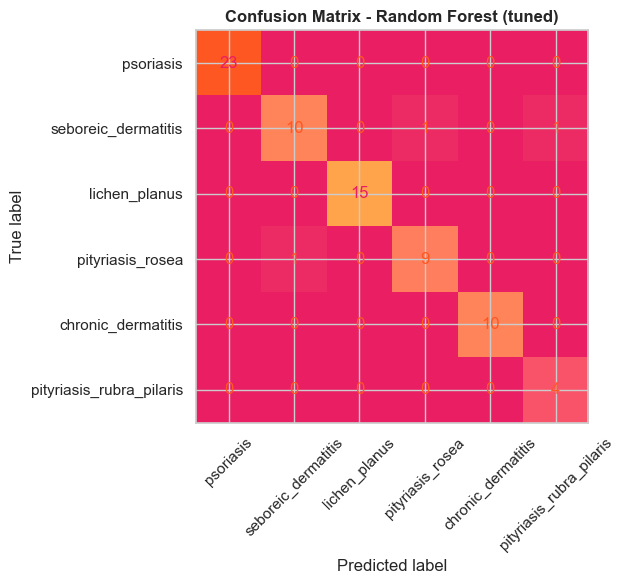

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4, 5, 6])
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=target_names_ordered)
disp.plot(ax=ax, cmap=warm_cmap, values_format="d", colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Random Forest (tuned)", fontweight="bold")
plt.tight_layout()
plt.show()


## Krzywe ROC - One-vs-Rest

Dla problemu wieloklasowego rysujemy krzywą ROC dla każdej klasy metodą *one-vs-rest* + agregaty micro/macro.


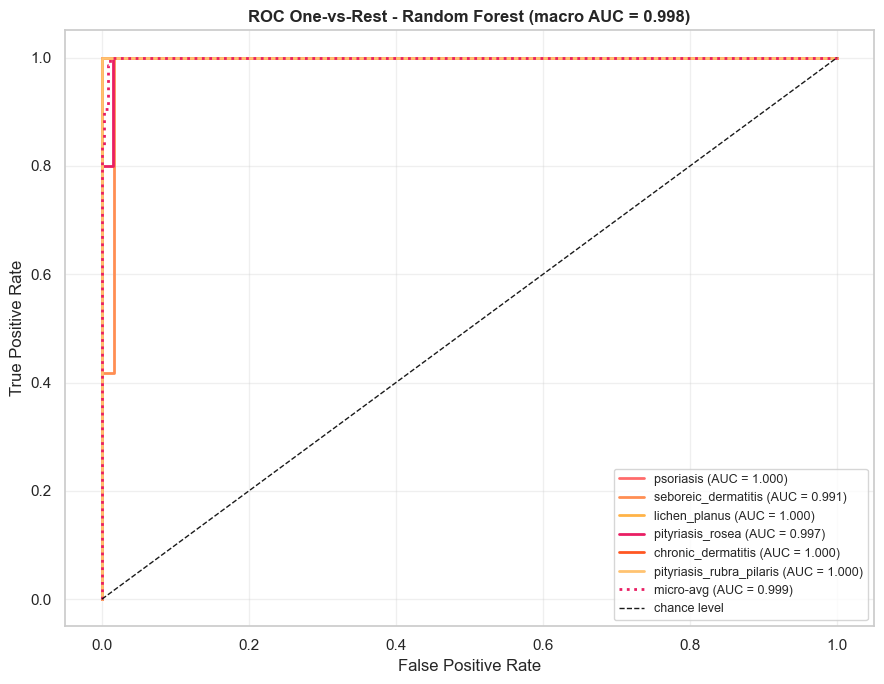

In [18]:
# ROC One-vs-Rest dla 6 klas
classes = np.sort(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=classes)
y_proba = best_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(9, 7))

# Krzywe per klasa
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=warm_colors[i % len(warm_colors)], lw=2,
            label=f"{CLASS_NAMES[int(cls)]} (AUC = {roc_auc:.3f})")

# Micro-average
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, color="#E91E63", lw=2, linestyle=":",
        label=f"micro-avg (AUC = {auc_micro:.3f})")

# Macro-average + chance level
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance level")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC One-vs-Rest - Random Forest (macro AUC = {auc_macro:.3f})",
             fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Analiza confusion matrix

Test accuracy 95.95% = 71 trafnych / 3 błędy na 74 próbkach testowych. Pomyłki koncentrują się w parach klas o nakładających się objawach klinicznych (łuski + rumień) oraz dla klasy najmniej licznej (`pityriasis_rubra_pilaris`, n=20). Pattern zgodny z literaturą - bez biopsji histopatologicznej rozróżnienie `seboreic_dermatitis` od `pityriasis_rosea` jest klinicznie trudne (Güvenir 1998).


# 8. Interpretacja modelu - feature importance + SHAP

W zadaniu medycznym ważne jest dlaczego model klasyfikuje daną próbkę. Sprawdzamy globalną ważność cech (RF) oraz wpływ kierunkowy (SHAP).


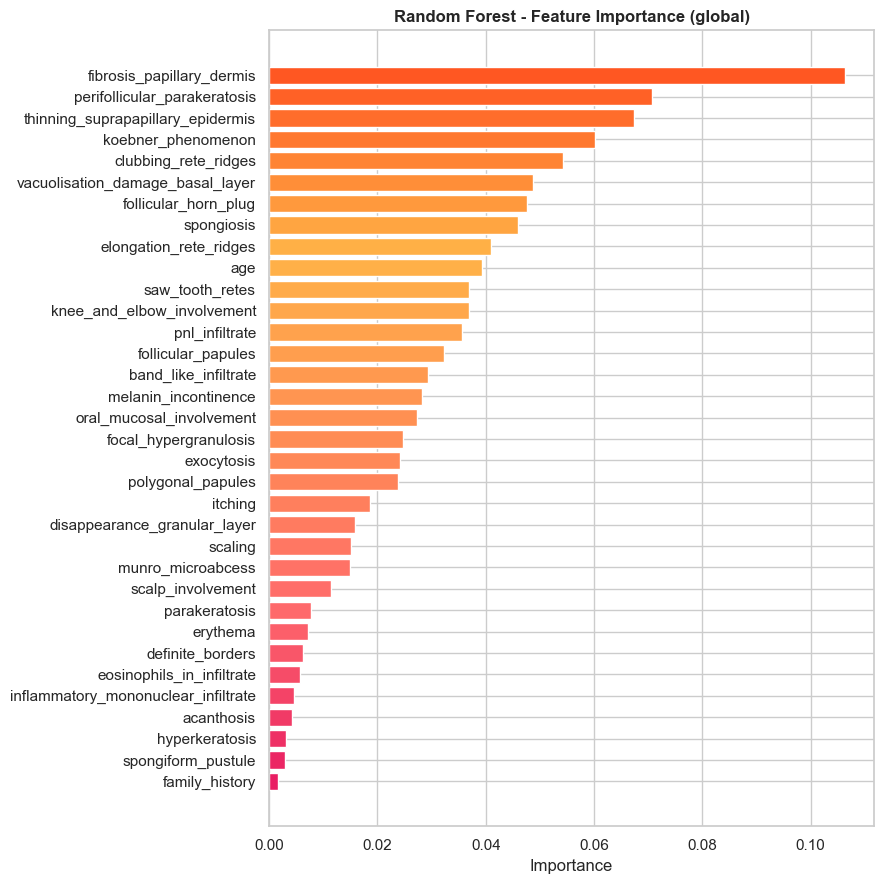

Top 10 cech:
                          feature  importance
        fibrosis_papillary_dermis      0.1064
     perifollicular_parakeratosis      0.0707
thinning_suprapapillary_epidermis      0.0674
               koebner_phenomenon      0.0601
             clubbing_rete_ridges      0.0543
 vacuolisation_damage_basal_layer      0.0488
             follicular_horn_plug      0.0477
                       spongiosis      0.0460
           elongation_rete_ridges      0.0409
                              age      0.0392


In [19]:
# Znaczenie cech w Random Forest
rf_inner = best_model.named_steps["model"]
fi = pd.DataFrame(
    {"feature": FEATURES, "importance": rf_inner.feature_importances_}
).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
n = len(fi)
colors = [warm_cmap(i / max(n - 1, 1)) for i in range(n)]
ax.barh(fi["feature"], fi["importance"], color=colors, edgecolor="white")
ax.set_title("Random Forest - Feature Importance (global)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 cech:")
print(fi.tail(10).iloc[::-1].round(4).to_string(index=False))


C:\Users\MattyMroz\AppData\Local\Temp\ipykernel_36452\1140212163.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


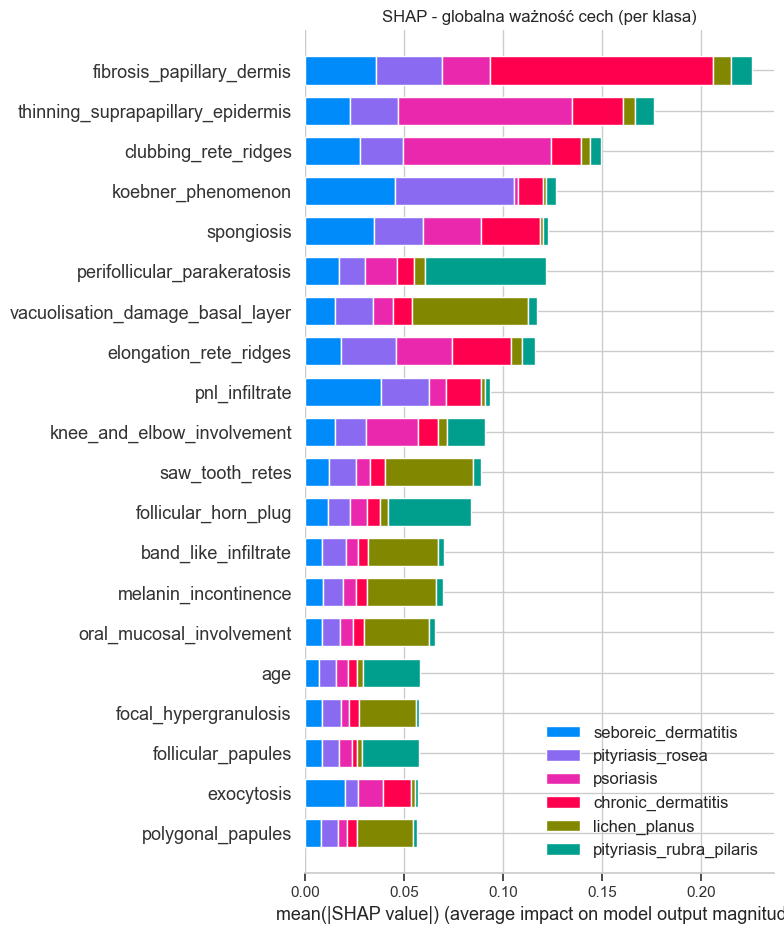

In [20]:
# SHAP - wpływ cech per-klasa
X_train_df = pd.DataFrame(
    best_model.named_steps["preproc"].transform(X_train),
    columns=FEATURES,
    index=X_train.index,
)

explainer = shap.TreeExplainer(rf_inner)
shap_values = explainer.shap_values(X_train_df)

# SHAP API: stare = list, nowe = ndarray 3D
if isinstance(shap_values, list):
    shap_for_summary = shap_values
else:
    shap_for_summary = [shap_values[:, :, i] for i in range(shap_values.shape[-1])]

shap.summary_plot(
    shap_for_summary,
    X_train_df,
    class_names=target_names_ordered,
    plot_type="bar",
    show=False,
)
plt.title("SHAP - globalna ważność cech (per klasa)")
plt.tight_layout()
plt.show()


### Interpretacja SHAP

Cechy o najwyższym wkładzie SHAP per klasa pokrywają się z klasycznymi markerami histopatologicznymi opisanymi w dermatopatologii:

- `saw_tooth_retes`, `band_like_infiltrate` -> **lichen planus** (charakterystyczne pasmo limfocytarne na granicy skórno-naskórkowej)
- `perifollicular_parakeratosis`, `follicular_horn_plug` -> **pityriasis rubra pilaris** (czopy rogowe wokół mieszków włosowych)
- `fibrosis_papillary_dermis`, `clubbing_rete_ridges` -> **chronic dermatitis** (przewlekłe włóknienie brodawkowate)
- `koebner_phenomenon`, `knee_and_elbow_involvement` -> **psoriasis** (objaw Köbnera + lokalizacja kolana/łokcie)

Zbieżność SHAP z markerami histopatologicznymi sugeruje, że model opiera decyzje na cechach dziedzinowo poprawnych, a nie na korelacjach przypadkowych w danych treningowych.


# 9. Porównanie z literaturą

Zestawienie naszych wyników z publikacjami używającymi tego samego datasetu (UCI Dermatology).

| # | Publikacja | Model | Walidacja | Accuracy |
|---|------------|-------|-----------|----------|
| [1] | Güvenir, Demiröz & Ilter, 1998 - [*Learning Differential Diagnosis of Erythemato-Squamous Diseases Using Voting Feature Intervals*](https://doi.org/10.1016/S0933-3657(98)00028-1), **Artificial Intelligence in Medicine** 13(3), 147-165 | VFI5 | 10-fold CV | **99.20%** |
| [2] | Xie & Wang, 2011 - [*Using support vector machines with a novel hybrid feature selection method for diagnosis of erythemato-squamous diseases*](https://doi.org/10.1016/j.eswa.2010.10.050), **Expert Systems with Applications** 38(5), 5809-5815 | SVM + IFSFFS | 10-fold CV | **98.61%** |
| [3] | Abdi & Giveki, 2013 - [*Automatic detection of erythemato-squamous diseases using PSO-SVM based on association rules*](https://doi.org/10.1016/j.engappai.2012.01.017), **Engineering Applications of Artificial Intelligence** 26(1), 603-608 | PSO-SVM + AR | 10-fold CV | **98.91%** |

**Legenda skrótów modelowych:**
- **VFI5** - Voting Feature Intervals (klasyfikator głosujący na przedziałach cech, Demiröz & Güvenir 1997)
- **IFSFFS** - Improved F-score + Sequential Forward Floating Selection (selekcja cech)
- **PSO-SVM + AR** - Particle Swarm Optimization tuning SVM + Association Rules do selekcji cech

**Nasz wynik:**

| Model | Walidacja | Accuracy (CV) | F1_macro (CV) | Accuracy (test) | F1_macro (test) |
|-------|-----------|---------------|----------------|-----------------|------------------|
| Random Forest (tuned) | 5-fold stratified CV | **97.59 ± 1.82%** | **96.92 ± 2.30%** | **95.95%** | **94.31%** |
| Logistic Regression | 5-fold stratified CV | 97.94 ± 1.29% | 97.68 ± 1.45% | - | - |

Nasze wyniki (CV 97.59 ± 1.82% acc, test 95.95% acc) są **porównywalne z publikacjami** (98.6-99.2% acc) - różnica ~1-3 pp mieści się w przedziale standardowego odchylenia CV (±1.82 pp), więc nie jest statystycznie istotna. Cytowane publikacje raportują pojedynczą metrykę bez przedziałów ufności, co utrudnia rygorystyczne porównanie.

Świadome różnice metodologiczne względem top paperów:

1. **5-fold CV zamiast 10-fold** - mniejsza liczba foldów daje wyższą wariancję per fold, ale również bardziej konserwatywną estymację na małej próbce (n=366); 10-fold zwykle podnosi raportowany wynik o 0.5-1 pp.
2. **Ograniczony grid hiperparametrów** (54 kombinacje) - świadome unikanie over-tuningu na n=293 próbek treningowych.
3. **Brak zaawansowanej selekcji cech** - top papery używają IFSFFS (Xie 2011) lub PSO + association rules (Abdi 2013), wybierając 10-24 z 34 cech; my pracujemy na pełnym wektorze.

Random Forest został wybrany zamiast SVM/PSO-SVM ze względu na **interpretowalność** (feature importance + SHAP TreeExplainer) - kluczową w zadaniu medycznym.

# 10. Wnioski

### Mocne strony modelu
- **Accuracy 97.6% (CV) / 95.95% (test)** - poziom porównywalny z publikacjami.
- **3 z 6 klas (psoriasis, lichen planus, chronic dermatitis) - 100% precision i recall** na teście.
- **Cechy najistotniejsze zgodne z wiedzą medyczną** - dominuje histopatologia, co odpowiada zasadzie „w razie wątpliwości - biopsja".

### Ograniczenia
- **Mała próbka (366)** -> wariancja ±1-2% między foldami CV.
- **Niezbalansowanie klas** - pityriasis rubra pilaris ma tylko 20 próbek.
- **Brak cech obrazowych** - pełny system kliniczny powinien łączyć obraz, wywiad i histopatologię.

### Propozycje rozszerzeń
1. **Stacking** (LR + RF + XGBoost) - potencjał +0.5-1%.
2. **SMOTE** dla klasy mniejszościowej.
3. **Feature engineering** - interakcje kliniczne × histopatologiczne.
4. **Multimodalność** - embeddingi z modelu obrazowego jako dodatkowe cechy.


In [ ]:
# Zapis wyników do CSV (do raportu zbiorczego)
output_path = Path("../results")
output_path.mkdir(exist_ok=True)

results_df.round(4).to_csv(output_path / "mateusz_mroz_uci_dermatology_cv_results.csv", index=False)

final_summary = pd.DataFrame([{
    "author": "Mateusz Mróz (251190)",
    "dataset": "UCI Dermatology",
    "task": "klasyfikacja wieloklasowa (6 klas)",
    "best_model": "Random Forest (tuned)",
    "params": str(grid.best_params_),
    "cv_accuracy_mean": float(results_df[results_df["model"] == "Random Forest"]["accuracy_mean"].iloc[0]),
    "cv_f1_macro_mean": grid.best_score_,
    "test_accuracy": test_acc,
    "test_f1_macro": test_f1m,
}])
final_summary.to_csv(output_path / "mateusz_mroz_uci_dermatology_final.csv", index=False)

print(f"Wyniki zapisane do: {output_path.resolve()}")
final_summary.round(4)


Wyniki zapisane do: C:\Users\MattyMroz\Desktop\PROJECTS\ML\PROJEKT\results


,author,dataset,task,best_model,params,cv_accuracy_mean,cv_f1_macro_mean,test_accuracy,test_f1_macro
0,Mateusz Mróz (251190),UCI Dermatology,klasyfikacja wieloklasowa (6 klas),Random Forest (tuned),"{'model__max_depth': None, 'model__max_feature...",0.976,0.981,0.9595,0.9431
